# Summary - Process Trees EDA

### Build graph $G$ and find the connected components (process trees)
1. From the ```process_uber_summary``` table, build an ```igraph``` directed graph $G$ where each edge is of the form: ```parent PID --> child PID```
2. Get all (weak) connected components from $G$ -- those are the ```process trees``` (with one exception where a loop is present, which we drop), and save those in the **Trees** object
    * 99.98% of components are of size 2 (1,111,052  out of 1,111,278) ...
    * 210 process trees contain between 3 and 10k nodes
    * 15 have more then 10k nodes
3. Identify all process (sub)trees of size 3 to 10k inclusively ; store this info in a dataframe

### Scoring function
Enrich $G$ with metadata for each PID in the form of dictionaries:
* Pid -> process name
* Pid -> user name
* Pid -> embedding (from numerical features, done in a different notebook)
* process name -> frequeny
Those will be used to define various scoring functions, such as:
* binary match on process name
* binary match on process name and user name
* similarity in embedded space
* binary match on process name along with inverse process frequency score


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import seaborn as sns
from collections import Counter
import igraph as ig
import pickle
import gzip
import logging as lg
import re

## our matching algorithm
import sys
import os
sys.path.insert(0,os.path.abspath('../Matching'))
import igraph_io as igio
import gw_matcher as gwm ## older code - for testing
import fast_match as fm  ## fast version
import needleman_wunsch_tree as nwt ## slower, more flexibility for scoring functions

## several utility functions
import process_trees as pt


# Build process trees from the ```process_uber_summary``` table


In [3]:
process_summary = pd.read_parquet("Data/process_uber_summary.parquet", columns=['pid_hash', 'parent_pid_hash', 'process_name', 'user_name', 'red_team'] )
process_summary.head()


,pid_hash,parent_pid_hash,process_name,user_name,red_team
0,A86DB324303BBC24B4C279909AC5AD00,B066C89E8047845304C38E8BEE22AD90,powershell.exe,ACME\user10,1
1,C194ECED319F84EC8DAED02EE44FCE63,450735D5CC2CCEC4C8B12EC8818120E8,wmic.exe,None,0
2,FA50BB30E957D73120420F46B18AE167,450735D5CC2CCEC4C8B12EC8818120E8,wmic.exe,None,0
3,5803C60CEB8387DFA7ADA3E5E75E88FF,6FB634509A57999E72BCAFA74A8FFF29,wmic.exe,None,0
4,3BD26DAC90333D99453E9F506A514B1B,6FB634509A57999E72BCAFA74A8FFF29,wmic.exe,None,0


In [10]:
def extract_process_trees(process, uid='pid_hash', parent_uid='parent_pid_hash', extra=None, min_tree_size=3, max_tree_size=100):

    ## keep required columns
    df = process.drop_duplicates()
    
    ## parents and children
    child = set(df[uid])
    parent = set(df[parent_uid]) ## Can be 'None', we'll delete later
    
    ## node dictionaries
    nodes = parent.union(child)
    nodes_dict = {v:k for k,v in enumerate(nodes)}
    inv_nodes_dict = {k:v for k,v in enumerate(nodes)}

    ## build directed graph from edgelist
    child = [nodes_dict[x] for x in df[uid]]
    parent = [nodes_dict[x] for x in df[parent_uid]]
    edges = np.array([parent,child]).T
    G = ig.Graph.TupleList(edges, directed=True)
    G = G.simplify() ## there are self-edges
    G.vs['uid'] = [inv_nodes_dict[int(x)] for x in G.vs['name']]

    ## find all connected components a.k.a. process trees (with one exception)
    Trees = G.connected_components(mode="weak")
    G.vs['tree'] = Trees.membership

    ## drop trees of size < min_tree_size and non-tree(s)
    _dct = dict(enumerate(Trees.sizes()))
    G.vs['tree_size'] = [_dct[i] for i in G.vs['tree']]
    roots = np.where(np.array(G.degree(mode='in'))==0)
    non_tree = set(np.array(G.vs['tree'])).difference(set(np.array(G.vs['tree'])[roots]))
    G.delete_vertices([v for v in G.vs if (v['tree_size']<min_tree_size or v['tree_size']>max_tree_size or v['tree'] in non_tree)])

    ## re-compute 
    Trees = G.connected_components(mode="weak")
    G.vs['tree'] = Trees.membership
    del G.vs['name']

    ## add some node features
    if extra:
        for i, (feature,name) in enumerate(extra.items()):
            user_dict = dict(zip(df[uid],df[feature]))
            G.vs[name] = [user_dict.get(x, '') for x in G.vs['uid']]    
    return Trees

def acme_list_process_subtrees(G, process_name='process', min_tree_size=3):
    L = []

    for v in G.vs:
        process = v[process_name]
        if G.degree(v, mode='out')>0 and process != '' and process != 'unknown': ## pick non-leaf nodes with some process name
            V, l, p = G.bfs(v.index)
            nodes = len(V)
            splits = sum([x>1 for x in list(Counter(np.array(p)[np.array(p)>=0]).values())])
            if nodes<min_tree_size: 
                continue
            leaves = nodes - len(set(np.array(p)[np.array(p)>=0]))
            layers = len(l)-1

            ## acme specific
            b3 = len([_username.get(x,'') for x in G.vs[V]['uid'] if x is not None and 'baduser3' in x])
            b9 = len([_username.get(x,'') for x in G.vs[V]['uid'] if x is not None and 'baduser9' in x])
            b25 = len([_username.get(x,'') for x in G.vs[V]['uid'] if x is not None and 'baduser25' in x])
            red = sum([_marker.get(x,0) for x in G.vs[V]['uid']])
            
            x = [v.index, process, nodes, layers, leaves, b3, b9, b25, red]
            L.append(x)

    return pd.DataFrame(L, columns=['root','process','nodes','layers','leaves','bad3','bad9','bad25','redteam'])


In [5]:
## utility function - extract subgraph from VertexClustering object
def acme_get_bfs_subtree(Trees, tree_id, root_id):
    
    ## get subtree
    g = Trees.subgraph(tree_id)

    ## bfs ordering
    nodes, _ , parent = g.bfs(root_id)
    
    ## save vertices in new graph
    G = ig.Graph(directed=True)
    names = [str(g.vs['uid'][i]) for i in nodes] ## in BFS order
    G.add_vertices(names)
    
    ## save attributes in same order    
    for att in g.vs.attribute_names():
        G.vs[att] = [g.vs[att][i] for i in nodes]
    
    ## add edges
    E = [(str(g.vs['uid'][parent[i]]),str(g.vs['uid'][i])) for i in nodes if parent[i]>=0]
    G.add_edges(E)    

    del G.vs['name']
    
    return G


In [6]:
%%time
Trees = extract_process_trees(process_summary, max_tree_size=10000, extra={'process_name':'process','user_name':'user','red_team':'redteam'})


CPU times: user 12.7 s, sys: 685 ms, total: 13.4 s
Wall time: 13.5 s


In [7]:
Trees.graph.vs[0]

igraph.Vertex(<igraph.Graph object at 0x300812cf0>, 0, {'uid': 'B8B7829B8BF55D5A1DB5C67F873720B6', 'tree': 0, 'tree_size': 9471, 'process': 'unknown', 'user': None, 'redteam': 0})

In [25]:
_username = dict(zip(process_summary.pid_hash,process_summary.user_name))
_marker = dict(zip(process_summary.pid_hash,process_summary.red_team))
_processname = dict(zip(process_summary.pid_hash,process_summary.process_name))


In [26]:
df_trees = pd.DataFrame()
for t in range(len(Trees)):
    _df = acme_list_process_subtrees(Trees.subgraph(t))
    _df.insert(loc=0, column='tree', value=t)
    df_trees = pd.concat([df_trees,_df])
df_trees

,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,redteam
0,0,40,ssm-document-worker.exe,7,2,6,0,0,0,0
1,0,44,ngentask.exe,4,2,3,0,0,0,0
2,0,74,sppextcomobj.exe,3,2,2,0,0,0,0
3,0,162,ngentask.exe,4,2,3,0,0,0,0
4,0,212,compattelrunner.exe,5,2,4,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1,169,4,conhost.exe,4,4,1,0,0,0,0
0,172,0,conhost.exe,3,3,1,0,0,0,0
0,174,2,conhost.exe,3,3,1,0,0,0,0
0,192,1,conhost.exe,3,3,1,0,0,0,0


In [30]:
## for plotting - red_team nodes in red
Trees.graph.vs['label_color'] = 'black'
Trees.graph.vs['color'] = 'black'
for v in Trees.graph.vs:
    if _marker.get(v['uid'],0)>0:
        v['label_color']='red'
        v['color']='red'

In [31]:
sg1 = acme_get_bfs_subtree(Trees, 14, 47)
sg2 = acme_get_bfs_subtree(Trees, 50, 194)


In [32]:
proc_counts = Counter([_processname.get(v,'') for v in Trees.graph.vs['uid']])
_invfreq = {k: float(1/np.log2(v+1)) for k, v in proc_counts.items()} ## max score of 1 when v==1


### Matching - using partial and new code from Aaron's Git repo


In [33]:
from functools import partial

In [34]:
def _sm(a, b, _dct):
    return int(a==b)*(_dct[a])


In [35]:
split_match = partial(_sm, _dct=_invfreq)


In [44]:
# with gzip.open('Data/acme4_process_num_features_embedding_ecdf.pkl.gz', 'rb') as fp:
#     _emb = pickle.load(fp)


FileNotFoundError: [Errno 2] No such file or directory: 'Data/acme4_process_num_features_embedding_ecdf.pkl.gz'

In [ ]:
# def _sms(a, b, _dct):
#     return int(a[0]==b[0])*int(_dct[a[0]]>.18)


In [ ]:
# split_match = partial(_sms, _dct=_emb)


In [36]:
gwm.basic_matcher(sg1, sg2, phi_name='process', w=split_match) ## slower algorithm

([(np.int64(5), np.int64(12)), (1, 10), (0, 0)],
 np.float64(0.19679482348879662))

In [37]:
_sg1 = igio.igraph_to_treedata(sg1, phi_name='process')
_sg2 = igio.igraph_to_treedata(sg2, phi_name='process')


In [41]:
nwt.align_trees_algorithm1(_sg1, _sg2, w=split_match).score

0.19679482281208038

In [42]:
nwt.align_trees_algorithm1(_sg1, _sg2).path_internal

[(1, 10), (5, 12)]

In [43]:
nwt.align_trees_algorithm1(igio.igraph_to_treedata(sg1, phi_name='process'),igio.igraph_to_treedata(sg2, phi_name='process'), w=split_match)

AlignmentResult(path_internal=[(1, 10), (5, 12)], score=0.19679482281208038, end_internal=(5, 12), A=None, C=None)

In [358]:
_sg2

TreeData(parent=array([-1,  0,  0,  1,  1,  1,  1,  1,  4,  8,  8,  9, 10, 11, 11],
      dtype=int32), label=['smss.exe', 'winlogon.exe', 'csrss.exe', 'logonui.exe', 'userinit.exe', 'dwm.exe', 'atbroker.exe', 'fontdrvhost.exe', 'explorer.exe', 'devenv.exe', 'cmd.exe', 'microsoft.servicehub.controller.exe', 'conhost.exe', 'servicehub.vsdetouredhost.exe', 'servicehub.identityhost.exe'], orig_index=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int32))

In [ ]:
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()

In [56]:
%%time
## pick same base tree as above
tree = 14
root = 47
sg1 = acme_get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
#sg1.vs['newlabel'] = [(x,InvFreq[x]) for x in sg1.vs['process']]
sg1.vs['newlabel'] = [_processname.get(x,'') for x in sg1.vs['uid']]

min_score = .3

## filter subtrees and apply Matching Algorithm
_df = df_trees[ (df_trees.layers >= 4) & (df_trees.nodes < 80) ]
T = list(_df.tree)
R = list(_df.root)
L = list(_df.layers)
B = list(_df.redteam>0)
Results = []
for i in range(len(T)):
    if T[i] != tree:
        sg2 = acme_get_bfs_subtree(Trees, T[i], R[i])
        #sg2.vs['newlabel'] = [(x,InvFreq[x]) for x in sg2.vs['process']]
        sg2.vs['newlabel'] = [_processname.get(x,'') for x in sg2.vs['uid']]
        _, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## slower algorithm
        if score >= min_score: ## required min path length
            if B[i] == 0: ## look for subtrees without a baduser                
                Results.append([T[i],R[i],L[i],sg2.vcount(),_processname.get(sg2.vs[0]['uid'],''),score])
results_df = pd.DataFrame(Results, columns=['tree','root','layers','nodes','process','score'])
results_df.sort_values(by='score', ascending=False)


CPU times: user 2.11 s, sys: 116 ms, total: 2.23 s
Wall time: 2.23 s


,tree,root,layers,nodes,process,score
0,36,31,5,54,ntoskrnl.exe,0.305669
1,116,4,8,66,smss.exe,0.305669
2,116,5,7,64,winlogon.exe,0.305669
3,116,7,4,7,cmd.exe,0.305669
4,116,31,6,58,userinit.exe,0.305669
5,116,32,5,57,explorer.exe,0.305669


In [53]:
results_df[results_df.nodes==12]

,tree,root,layers,nodes,process,score
2,9,115,6,12,powershell.exe,0.217749
5,9,220,6,12,cmd.exe,0.217749
8,9,393,6,12,cmd.exe,0.217749
12,9,602,6,12,cmd.exe,0.217749
16,9,841,6,12,cmd.exe,0.217749
41,27,60,7,12,explorer.exe,0.217749
57,116,35,9,12,winlogon.exe,0.217749


In [58]:
paths, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## node feature == process name
score

np.float64(0.30566946388030813)

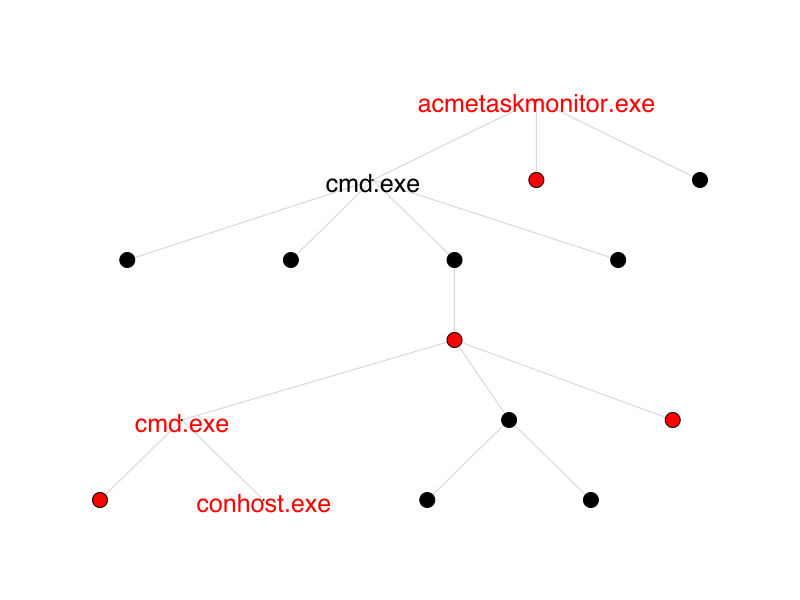

In [83]:
## pick one of the top hits and visualize common path (15 nodes, 7 layers)
tree = 36
root = 31
sg2 = acme_get_bfs_subtree(Trees, tree, root)
sg2.vs['newlabel'] = [_processname.get(x,'') for x in sg2.vs['uid']]
paths, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## node feature == process name

## plot reference tree
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 15
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 25
ig.plot(sg1, bbox=(800,600), layout=sg1.layout_reingold_tilford(), margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=[_processname.get(x,'') for x in sg1.vs['uid']],
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


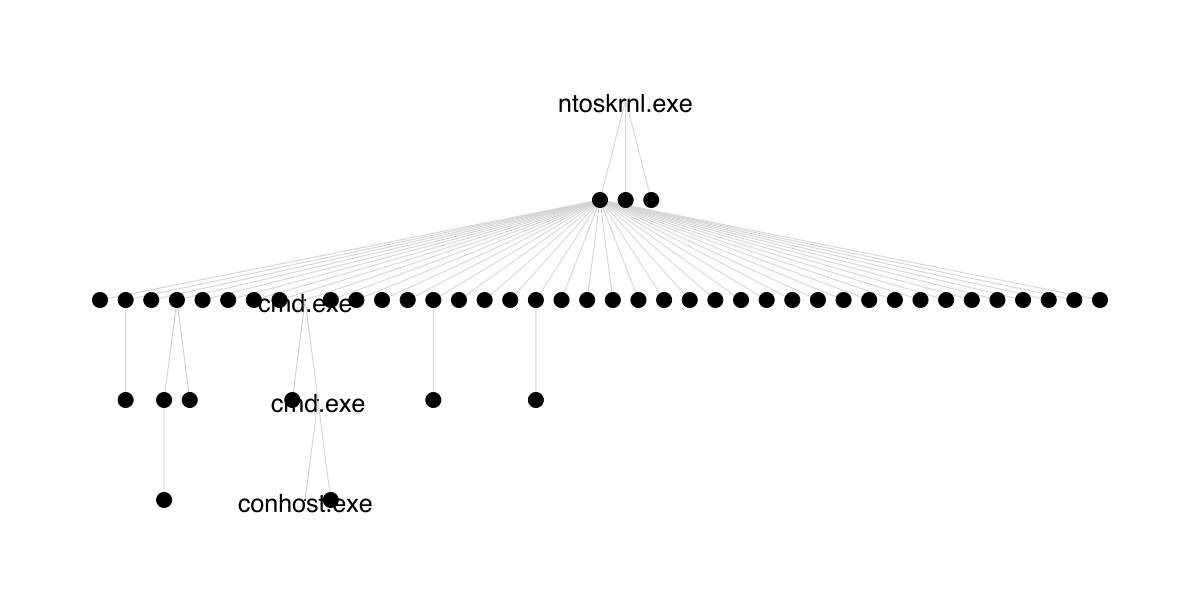

In [81]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 15
sg2.vs['vertex_label_size'] = 1
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 25
ig.plot(sg2, 
        bbox=(1200,600), layout=sg2.layout_reingold_tilford(), margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=[_processname.get(x,'') for x in sg2.vs['uid']],
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


In [256]:
[v for v in sg2.vs]

[igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 0, {'uid': 'E5ECF3CC867AF73D4AAA65509B789464', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'smss.exe', 'vertex_size': 1, 'vertex_label_size': 25}),
 igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 1, {'uid': '2596FF6053865E0B749041A29B1E6BD1', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'winlogon.exe', 'vertex_size': 15, 'vertex_label_size': 1}),
 igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 2, {'uid': 'E48D657328ACC887E40E4BB7E05E18BA', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'csrss.exe', 'vertex_size': 15, 'vertex_label_size': 1}),
 igraph.Vertex(<igraph.Graph object at 0x7fadf55d6150>, 3, {'uid': '63BB37E8D0540CEC020F3FB83FE15374', 'tree': 50, 'tree_size': 1031, 'label_color': 'black', 'vertex_color': 'black', 'newlabel': 'logonui.exe', 'vertex_size': 15, 'vertex_la

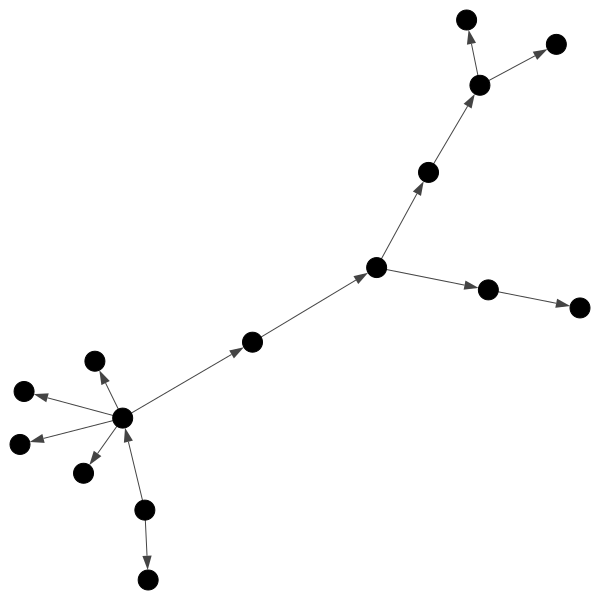

In [253]:
ig.plot(sg2, vertex_color = sg2.vs['vertex_color'])